# 시나리오 설명

## Task 1 Process

Task 1 학습 및 결과 추출
* Task 1 의 데이터과 레이블은 구성되어 있다 가정함
* Task 1 에 대한 학습 진행 (Train 코드는 script 실행 활용, dist 사용 필요하기 때문)
* Task 1 에 대한 Predict unknown objects and save results

Prediction results 시각화
* 4가지 시각화 데이터 생성 
    1. Prediction
    2. Ground Truth \[Known & Unknown\]
    3. Known GT와 안 겹치는 Prediction: 이미 학습한 클래스를 제거하여 시각화
    4. Unknown GT와 겹치는 Prediction: Future GT class와 비교하여 얼마나 모델이 unknown objects를 포착하고 있는지 시각화 (우리의 편의를 위해 만든 뷰)

유저 피드백 1단계
시각화 및 필터링

1. 모든 unknown object 시각화
2. 유저가 confidence threshold 설정
3. 추출된 unknown object 만 태깅해서 모으기
4. Annotation 진행 (CVAT or T-Rex API)

유저 피드백 2단계
1. T-Rex를 통해 추출된 annotation을 유저가 필터링
2. or CVAT를 통해 추출된 annotation을 유저가 필터링
3. CVAT를 통해 최종 annotation 생성

## Process Task 2 → Task 3 → Task 4 → Task 5

ETC: 새로운 태스크 진행할 때마다 실행해야 하는 함수 
* build model (invalid classes logit 처리 때문)
* set dataset
* (optional) load weights
* select between training data and test data

TODO
* 각 태스크 종료시 torch.cuda.empty_cache() 실행하여 GPU 메모리 확보.
* 노트북 다시 정리하면서 함수 정의 위치 옮길 예정

# 라이브러리 정리

In [1]:
import os
import json
import math
import shutil
import random
import collections
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from collections import defaultdict
import matplotlib.patches as patches

import fiftyone as fo
import fiftyone.utils.iou as foui
from fiftyone import ViewField as F

import torch
from torch.utils.data import DataLoader

import util.misc as utils
from models import build_model
from datasets.coco import make_coco_transforms
from datasets.open_world_eval import OWEvaluator
from datasets.torchvision_datasets.open_world import OWDetection
from engine import evaluate, train_one_epoch, get_exemplar_replay

from trex.visualize import visualize
from trex.model_wrapper import TRex2APIWrapper

import wandb

# arguments
from args import ARGS

# CUDA_ENVISIBLE_DEVICES
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

/workspace/.local/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'OWDETR': ('aeroplane', 'bicycle', 'bird', 'boat', 'bus', 'car', 'cat', 'cow', 'dog', 'horse', 'motorbike', 'sheep', 'train', 'elephant', 'bear', 'zebra', 'giraffe', 'truck', 'person', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'chair', 'diningtable', 'pottedplant', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'bed', 'toilet', 'sofa', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'tvmonitor', 'bottle', 'unknown'), 'TOWOD': ('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',

# Utility functions

In [2]:
# functions from main_open_world.py
def get_datasets(args):
    print(args.dataset)

    train_set = args.train_set
    test_set = args.test_set
    dataset_train = OWDetection(args, args.data_root, image_set=args.train_set, transforms=make_coco_transforms(args.train_set), dataset = args.dataset)
    dataset_val = OWDetection(args, args.data_root, image_set=args.test_set, dataset = args.dataset, transforms=make_coco_transforms(args.test_set))

    print(args.train_set)
    print(args.test_set)
    print(dataset_train)
    print(dataset_val)

    return dataset_train, dataset_val

# load weight function
def load_model_weights(model, checkpoint_path):
    # load temp model to do evaluation
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model'], strict=False)
    unexpected_keys = [k for k in unexpected_keys if not (k.endswith('total_params') or k.endswith('total_ops'))]
    if len(missing_keys) > 0:
        print('Missing Keys: {}'.format(missing_keys))
    if len(unexpected_keys) > 0:
        print('Unexpected Keys: {}'.format(unexpected_keys))
    return model

# print class names
def print_in_chunks_aligned(label, elements, chunk_size=5, width=20):
    """
    Print elements in fixed-width columns for better readability.
    
    :param label: Title to print
    :param elements: List of elements to print
    :param chunk_size: Number of elements per row
    :param width: Fixed width for each element
    """
    print(label)
    for i in range(0, len(elements), chunk_size):
        chunk = elements[i:i + chunk_size]
        # 각 원소를 고정 너비로 정렬하여 출력
        print(''.join(f"{el:<{width}}" for el in chunk))

# function from OWDetection class in PROB/datasets/torchvision_datasets/open_world.py 
def parse_voc_xml(node):
    voc_dict = {}
    children = list(node)
    if children:
        def_dic = collections.defaultdict(list)
        for dc in map(parse_voc_xml, children):
            for ind, v in dc.items():
                def_dic[ind].append(v)
        if node.tag == 'annotation':
            def_dic['object'] = [def_dic['object']]
        voc_dict = {
            node.tag:
                {ind: v[0] if len(v) == 1 else v
                    for ind, v in def_dic.items()}
        }
    if node.text:
        text = node.text.strip()
        if not children:
            voc_dict[node.tag] = text
    return voc_dict

# Pre-Setting

preset : 모든 태스크 종료시까지 변하지 않는 세팅

* base arguments 설정
* device 설정
* seed 설정

In [3]:
# get arguments
args = ARGS # TODO: config 파일로 변경

# set device
device = torch.device(args.device)

# fix the seed for reproducibility
seed = args.seed
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Task 1

## Arguments 설정

In [4]:
args.PREV_INTRODUCED_CLS = 0
args.CUR_INTRODUCED_CLS = 20

# pre-trained model weights 
args.checkpoint_path = 'exps/MOWODB/t1.pth'

# if True, the model will predict the training set
# training set에 prediction 진행할지 여부 (test set이 데이터양이 적어서 일단 test set으로 진행)
args.run_prediction_on_train = False

# if True, execute run prediction process
# 이전에 실행하여 결과값 저장되어 있는 경우를 위해 중복 실행 방지
args.run_prediction = False

# how many samples to visualize
args.NUM_VIS = 5000

# visualization dataset name
args.vis_dataset = 't1_c20_test'

## Task 1 데이터 학습 (TODO: 추후 현창이 설정으로 수정 예정)

In [5]:
# # 환경 변수 설정
# os.environ["EXP_DIR"] = "/path/to/exp_dir"  # EXP_DIR의 실제 경로
# os.environ["WANDB_NAME"] = "example_wandb_name"  # 원하는 WANDB 이름
# os.environ["PY_ARGS"] = ""  # 필요하면 추가 인자를 설정

# # 명령어 실행
# !python -u main_open_world.py \
#     --output_dir "${EXP_DIR}/t1" --dataset TOWOD --PREV_INTRODUCED_CLS 0 --CUR_INTRODUCED_CLS 20 \
#     --train_set 'owod_t1_train' --test_set 'owod_all_task_test' --epochs 41 \
#     --model_type 'prob' --obj_loss_coef 8e-4 --obj_temp 1.3 \
#     --wandb_name "${WANDB_NAME}_t1" --exemplar_replay_selection --exemplar_replay_max_length 850 \
#     --exemplar_replay_dir ${WANDB_NAME} --exemplar_replay_cur_file "learned_owod_t1_ft.txt" \
#     ${PY_ARGS}


## Predict and extract unknown objects

### Prediction 이전에 세팅 사항
1. build model
2. set dataset
3. (optional) load weights
4. select between training data and test data in arguments

In [6]:
# build model
model, criterion, postprocessors, exemplar_selection = build_model(args, mode = args.model_type)
model.to(device)

print(f'Backbone: {model.__class__.__name__}')
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of params:', n_parameters)

# set dataset
dataset_train, dataset_val = get_datasets(args)

sampler_train = torch.utils.data.RandomSampler(dataset_train)
sampler_val = torch.utils.data.SequentialSampler(dataset_val)

batch_sampler_train = torch.utils.data.BatchSampler(sampler_train, args.batch_size, drop_last=True)
data_loader_train = DataLoader(dataset_train, batch_sampler=batch_sampler_train,
                                collate_fn=utils.collate_fn, num_workers=args.num_workers,
                                pin_memory=True)
data_loader_val = DataLoader(dataset_val, args.batch_size, sampler=sampler_val,
                                drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers,
                                pin_memory=True)

# (optional) load weights
if args.checkpoint_path:
    # load temp model to do evaluation
    model = load_model_weights(model, args.checkpoint_path)

Invalid class range: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]
DINO resnet50


/workspace/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/workspace/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


running with exemplar_replay_selection
Backbone: DeformableDETR
number of params: 39742295
TOWOD
owod_t1_5classes_train
owod_all_task_test
Dataset OWDetection
    Number of datapoints: 23908
    Root location: data/OWOD
    [['train'], Compose(
    Compose(
)
)]
Dataset OWDetection
    Number of datapoints: 10246
    Root location: data/OWOD
    [['test'], Compose(
    Compose(
)
)]


### Prediction 실행

* data_loader와 base_ds 설정

In [7]:
# set data_loader and dataset
if args.run_prediction_on_train:
    # toy dataset
    data_loader = data_loader_train
    base_ds = dataset_train
else:
    # test dataset
    data_loader = data_loader_val
    base_ds = dataset_val

num_classes = len(base_ds.CLASS_NAMES)
num_known_classes = args.PREV_INTRODUCED_CLS+args.CUR_INTRODUCED_CLS
num_unknown_classes = num_classes - num_known_classes - 1

# print the number of classes, length of dataset
print('Number of images:', len(base_ds))
print('Number of known classes:', num_known_classes)
print('Number of unknown classes:', num_unknown_classes)
# Known and Unknown classes
print_in_chunks_aligned('-- Known classes --', base_ds.CLASS_NAMES[:num_known_classes])
print_in_chunks_aligned('-- Unknown classes --', base_ds.CLASS_NAMES[num_known_classes:-1])

Number of images: 10246
Number of known classes: 20
Number of unknown classes: 60
-- Known classes --
aeroplane           bicycle             bird                boat                bottle              
bus                 car                 cat                 chair               cow                 
diningtable         dog                 horse               motorbike           person              
pottedplant         sheep               sofa                train               tvmonitor           
-- Unknown classes --
truck               traffic light       fire hydrant        stop sign           parking meter       
bench               elephant            bear                zebra               giraffe             
backpack            umbrella            handbag             tie                 suitcase            
microwave           oven                toaster             sink                refrigerator        
frisbee             skis                snowboard           sports b

In [8]:
# set model to evaluation mode
model.eval()
criterion.eval()
metric_logger = utils.MetricLogger(delimiter="  ")
header = 'Test:'
iou_types = tuple(k for k in ('segm', 'bbox') if k in postprocessors.keys())
coco_evaluator = OWEvaluator(base_ds, iou_types, args=args)

testing data details
81
80
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor')
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', 'truck', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'bed', 'toilet', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy b

In [9]:
if args.run_prediction:
    # run prediction
    for samples, targets in metric_logger.log_every(data_loader, 10, header):
        samples = samples.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        outputs = model(samples)

        orig_target_sizes = torch.stack([t["orig_size"] for t in targets], dim=0)
        results = postprocessors['bbox'](outputs, orig_target_sizes)

        res = {target['image_id'].item(): output for target, output in zip(targets, results)}
        if coco_evaluator is not None:
            coco_evaluator.update(res)
        
    # gather the stats from all processes
    metric_logger.synchronize_between_processes()
    # print("Averaged stats:", metric_logger)
    if coco_evaluator is not None:
        coco_evaluator.synchronize_between_processes()

    # accumulate predictions from all images
    if coco_evaluator is not None:
        coco_evaluator.accumulate()
        res = coco_evaluator.summarize()        
    stats = {k: meter.global_avg for k, meter in metric_logger.meters.items()}
    stats['metrics']=res
    if coco_evaluator is not None:
        if 'bbox' in postprocessors.keys():
            stats['coco_eval_bbox'] = coco_evaluator.coco_eval['bbox'].stats.tolist()

### Save results and load them for reuse

In [10]:
# Skip saving results if predictions were not run
if len(coco_evaluator.img_ids) == len(base_ds):
    # extract prediction results
    results = {
        'img_ids': coco_evaluator.img_ids,
        'predictions': coco_evaluator.lines,
        'cls': coco_evaluator.lines_cls,
        'cls_name': coco_evaluator._class_names,
    }
    # save results
    np.save('exps/MOWODB/t1_c20_test_results.npy', results)

# load results
results = np.load('exps/MOWODB/t1_c20_test_results.npy', allow_pickle=True).item()
cls_dict = {i: name for i, name in enumerate(results['cls_name'])}

## Visualize the predictions

* Predictions / Known ground truth / Unknown ground truth 결과값 저장.
* Unknown objects prediction 중 known object GT 와 IoU (0.6) 이상인 objects 필터링 함수
* Unknown objects prediction 중 unknown object GT 와 IoU (0.6) 이상인 objects 추출 함수

In [11]:
# Predictions
def get_pred_detections(img_id, preds, preds_cls, width, height, cls_dict, threshold=0.0):
    """
    Extracts detection results for a specific image from predictions.
    
    :param img_id: ID of the image for which predictions are being filtered
    :param preds: List of prediction results, each in the format [img_id, confidence, x1, y1, x2, y2]
    :param preds_cls: List of predicted class indices corresponding to preds
    :param width: Width of the original image (used for normalization)
    :param height: Height of the original image (used for normalization)
    :param cls_dict: Dictionary mapping class indices to class names
    :param threshold: Confidence threshold to filter predictions
    :return: List of FiftyOne `fo.Detection` objects representing predictions
    """
    # Validate inputs
    if not preds or not preds_cls:
        raise ValueError("Predictions and predicted classes cannot be empty.")
    if len(preds) != len(preds_cls):
        raise ValueError("Predictions and predicted classes must have the same length.")
    if width <= 0 or height <= 0:
        raise ValueError("Width and height must be positive.")

    # Filter predictions for the specific image and apply confidence threshold
    img_preds = [
        (pred, pred_cls) for pred, pred_cls in zip(preds, preds_cls)
        if pred[0] == img_id and pred[1] > threshold
    ]

    # Convert predictions to FiftyOne detections
    detections = []
    for pred, pred_cls in img_preds:
        # Normalize bounding box coordinates
        x_min = pred[2] / width
        y_min = pred[3] / height
        box_width = (pred[4] - pred[2]) / width
        box_height = (pred[5] - pred[3]) / height

        # Map class index to label
        label = cls_dict.get(pred_cls, f"Unknown_{pred_cls}")  # Fallback for unknown classes

        # Create FiftyOne detection
        detections.append(
            fo.Detection(
                label=label,
                bounding_box=[x_min, y_min, box_width, box_height],
                confidence=pred[1]
            )
        )

    return detections

# Ground truth (Known & Unknown)
def get_known_unknown_gt_detections(img_id, annotation_dir, width, height, known_classes):
    """
    Extracts ground truth detections from annotation files and separates them into known and unknown detections.
    
    :param img_id: ID of the image for which ground truth detections are being extracted
    :param annotation_dir: Directory containing Pascal VOC annotation XML files
    :param width: Width of the original image (used for normalization)
    :param height: Height of the original image (used for normalization)
    :param known_classes: Set of known class names
    :return: A tuple containing lists of known and unknown FiftyOne `fo.Detection` objects
    """
    # Path to the annotation file
    annot_path = os.path.join(annotation_dir, f"{img_id}.xml")
    
    # Check if annotation file exists
    if not os.path.exists(annot_path):
        raise FileNotFoundError(f"Annotation file not found: {annot_path}")
    
    # Parse the Pascal VOC XML annotation
    tree = ET.parse(annot_path)
    target = parse_voc_xml(tree.getroot())
    
    # Initialize lists for known and unknown detections
    known_gt_detections = []
    unknown_gt_detections = []

    # Extract objects from the annotation
    for obj in target['annotation'].get('object', []):
        label = obj["name"]
        
        # Convert bounding box to [0, 1] relative coordinates
        bbox = obj["bndbox"]
        x_min = float(bbox["xmin"]) / width
        y_min = float(bbox["ymin"]) / height
        x_max = float(bbox["xmax"]) / width
        y_max = float(bbox["ymax"]) / height
        bounding_box = [x_min, y_min, x_max - x_min, y_max - y_min]
        
        # Check if the label is a known class
        detection = fo.Detection(label=label, bounding_box=bounding_box)
        if label in known_classes:
            known_gt_detections.append(detection)
        else:
            unknown_gt_detections.append(detection)
    
    return known_gt_detections, unknown_gt_detections

# Unknown object prediction without overlap with the ground truth
def filter_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6):
    """
    Filters prediction bounding boxes that have IoU >= `iou_threshold` with any
    bounding box in known_ground_truth.

    :param sample: FiftyOne Sample containing predictions, known_ground_truth, and unknown_ground_truth
    :param iou_threshold: IoU threshold for filtering
    :return: List of filtered predictions
    """
    filtered_predictions = []
    # Get predictions and known_ground_truth detections
    predictions = sample["predictions"].detections
    unknown_predictions = [detect for detect in predictions if detect.label.startswith("unknown")]
    known_ground_truth = sample["known_ground_truth"].detections

    # Compute IoU matrix
    iou_matrix = foui.compute_ious(unknown_predictions, known_ground_truth)
    # Filter unknown object predictions where IoU > threshold with any known_ground_truth bbox
    row, _ = np.where(iou_matrix < iou_threshold)
    for i in np.unique(row):
        filtered_predictions.append(predictions[i])

    return filtered_predictions

# Unknown object prediction overlapping with the unknown ground truth
def extract_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6):
    """
    Extract prediction bounding boxes that have IoU >= `iou_threshold` with any
    bounding box in unknown_ground_truth.

    :param sample: FiftyOne Sample containing predictions, known_ground_truth, and unknown_ground_truth
    :param iou_threshold: IoU threshold for filtering
    :return: List of filtered predictions
    """
    filtered_predictions = []
    # Get predictions and known_ground_truth detections
    predictions = sample["predictions"].detections
    unknown_predictions = [detect for detect in predictions if detect.label.startswith("unknown")]
    unknown_ground_truth = sample["unknown_ground_truth"].detections

    # Compute IoU matrix
    iou_matrix = foui.compute_ious(unknown_predictions, unknown_ground_truth)
    # Filter unknown object predictions where IoU > threshold with any known_ground_truth bbox
    row, _ = np.where(iou_matrix >= iou_threshold)
    for i in np.unique(row):
        filtered_predictions.append(predictions[i])

    return filtered_predictions


### Create FiftyOne dataset

* args.NUM_VIS 설정이 5,000으로 전체 중 5,000개의 이미지만 시각화 진행
* 4가지 케이스의 데이터 생성 
    1. Prediction
    2. Ground Truth \[Known & Unknown\]
    3. Known GT와 안 겹치는 Prediction: 이미 학습한 클래스를 제거하여 시각화
    4. Unknown GT와 겹치는 Prediction: Future GT class와 비교하여 얼마나 모델이 unknown objects를 포착하고 있는지 시각화 (우리의 편의를 위해 만든 뷰)


In [12]:
# dataset directory
annotation_dir = os.path.join(args.data_root, 'Annotations')
image_dir = os.path.join(args.data_root, 'JPEGImages')

# Convert predictions' string to float
str2num = lambda x: [x.split()[0]] + [float(d) for d in x.split()[1:]]
preds = list(map(str2num, results['predictions']))
preds_cls = [cls.item() for cls in results['cls']]

# 캐시: 이미지 크기를 한 번만 가져오도록 딕셔너리 사용
img_size_cache = {}

# Create samples for your data
samples = []
for i in tqdm(range(args.NUM_VIS), desc="Processing Images"):
    img_id = preds[i * 100][0]
    img_path = os.path.join(image_dir, f"{img_id}.jpg")
    
    # 캐시된 이미지 크기 사용 또는 새로 가져오기
    if img_id not in img_size_cache:
        width, height = Image.open(img_path).size
        img_size_cache[img_id] = (width, height)
    else:
        width, height = img_size_cache[img_id]
        
    sample = fo.Sample(filepath=img_path)
    
    # 1.Prediction 필드 추가
    detections = get_pred_detections(img_id, preds, preds_cls, width, height, cls_dict)
    # Store detections in a field name of your choice
    sample["predictions"] = fo.Detections(detections=detections)
    
    # 2.Ground truth 필드 추가
    known_gt_detections, unknown_gt_detections = get_known_unknown_gt_detections(img_id, annotation_dir, width, height, coco_evaluator.known_classes)
    # Store detections in a field name of your choice
    sample["known_ground_truth"] = fo.Detections(detections=known_gt_detections)
    sample["unknown_ground_truth"] = fo.Detections(detections=unknown_gt_detections)
        
    # 3.Known GT와 겹치는 unknown 필터링
    preds_without_overlap_known_gt = filter_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6)
    # Optionally store filtered predictions in the sample
    sample["preds_without_overlap_known_gt"] = fo.Detections(detections=preds_without_overlap_known_gt)
    
    # 4.Unknown GT와 겹치는 unknown 추출
    preds_overlapping_unknown_gt = extract_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6)
    # Optionally store filtered predictions in the sample
    sample["preds_overlapping_unknown_gt"] = fo.Detections(detections=preds_overlapping_unknown_gt)
    
    samples.append(sample)

Processing Images: 100%|██████████| 5000/5000 [11:19<00:00,  7.36it/s]


In [13]:
print(f'Before FiftyOne dataset list: {fo.list_datasets()}')
if args.vis_dataset in fo.list_datasets():
    fo.delete_dataset(args.vis_dataset)
if 'bounding_box_visualization' in fo.list_datasets():
    fo.delete_dataset("bounding_box_visualization")
print(f'After FiftyOne dataset list: {fo.list_datasets()}')

Before FiftyOne dataset list: ['bounding_box_visualization', 't1_c20_test']
After FiftyOne dataset list: []


In [14]:
# Create dataset
print(args.vis_dataset)
dataset = fo.Dataset(args.vis_dataset)
dataset.add_samples(samples)
print(f'FiftyOne dataset list: {fo.list_datasets()}')

t1_c20_test
 100% |███████████████| 5000/5000 [3.4m elapsed, 0s remaining, 8.5 samples/s]       
FiftyOne dataset list: ['t1_c20_test']


In [15]:
# visualize
dataset_name = fo.list_datasets()[0]
dataset = fo.load_dataset(dataset_name)
session = fo.launch_app(dataset, auto=False)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

## 유저 피드백 1단계
### Confidence threshold filtering process

1. Threshold 0.0으로 하나의 이미지당 100개의 unknown object를 모두 시각화
2. 시각화를 통해 confidence score를 확인해 본 유저가 threshold를 설정 (e.g. 0.6)
3. (Tip) preds_overlapping_unknown_gt 같은 경우는 우리의 편의를 위해 만들어 놓은 뷰

In [37]:

# filtered_view = (
#     dataset.filter_labels("predictions", F("confidence") >= 0.6)
# )

# filtered_view = (
#     dataset.filter_labels("preds_without_overlap_known_gt", F("confidence") >= 0.6)
# )

filtered_view = (
    dataset.filter_labels("predictions", F("confidence") >= 0.6)
)

session.view = filtered_view

###  Annotation set selection
유저 필터링 반영 후 annotation할 데이터 추출

* 유저가 annotation 할 class 설정 (ex: cup, sink, bowl, potted plant, knife)
* Fiftyone에서 유저가 annotation 할 데이터에 대해 tag 설정
* Tagged data만 추출하여 annotation을 진행

Tip) 유저가 선택한 클래스를 unknown object prediction 와 unknown GT이 겹치는 케이스들에서 선택하여 진행.

In [18]:
annotation_view = dataset.match_tags("annotation")

In [19]:
session.view = annotation_view

Annotation 요청

1. CVAT
2. T-Rex API

### 1. CVAT 활용한 annotation

Install annotation-plugin
```
fiftyone plugins download \
    https://github.com/voxel51/fiftyone-plugins \
    --plugin-names @voxel51/annotation
```

* annotation 진행할 label_field, label_type, classes 지정.
    * label_field: 'annotations'
    * label_type: 'detections'
    * classes: ["cup", "sink", "bowl", "pottedplant", "knife"]

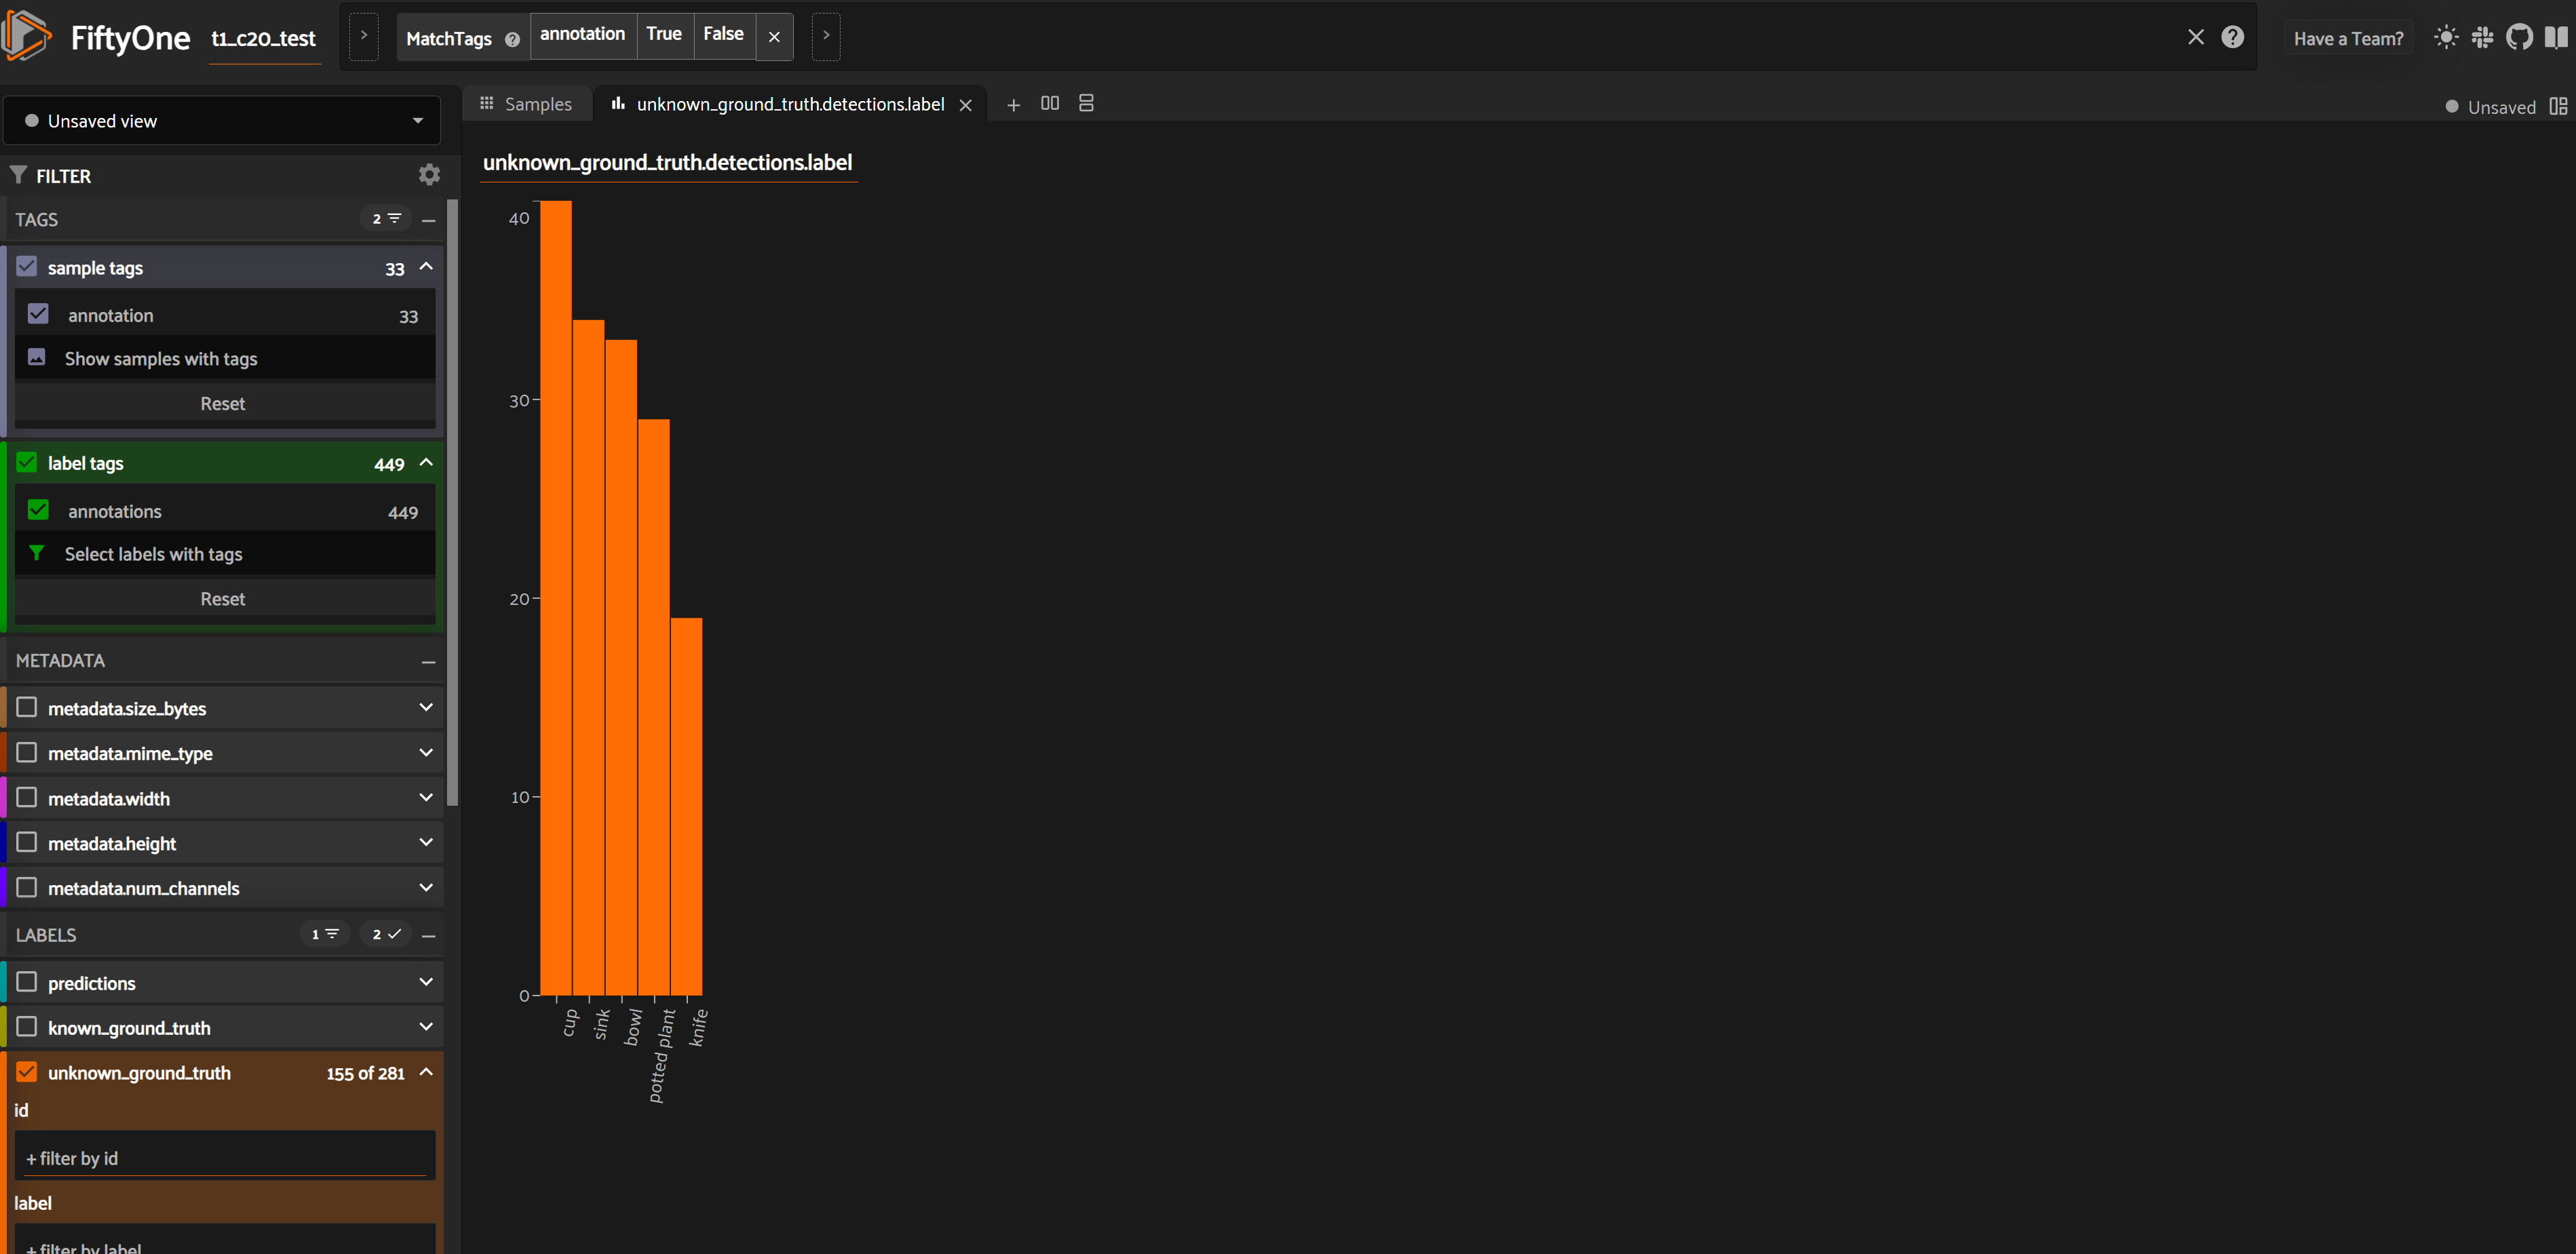

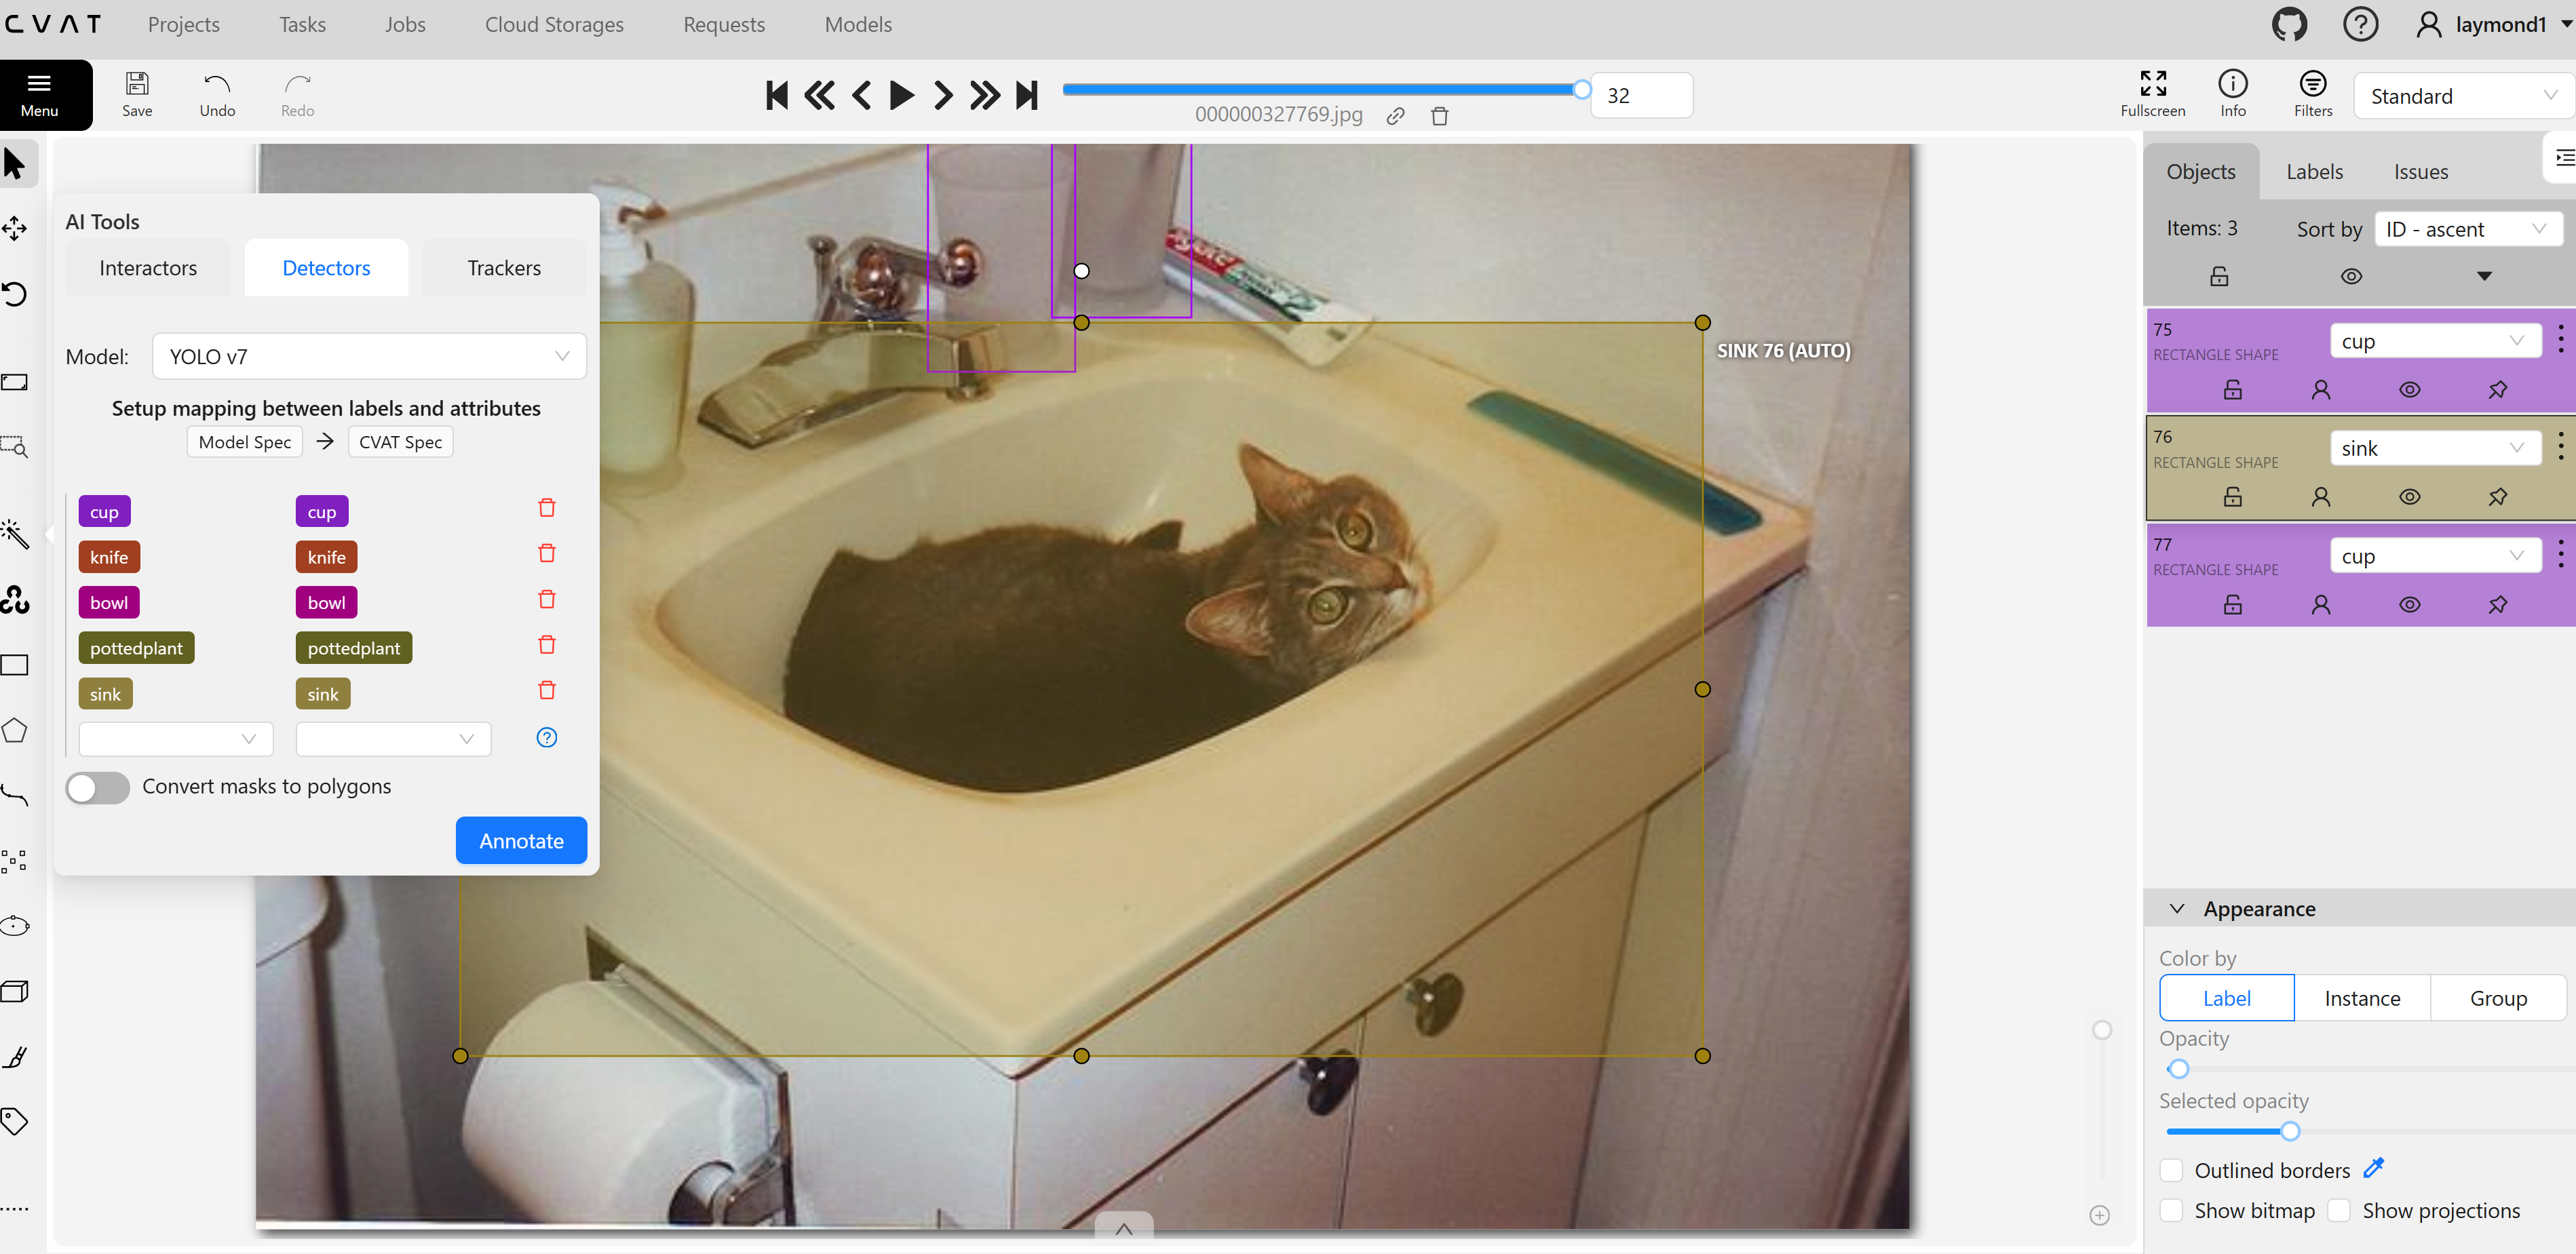

In [36]:
print(f'Before annotation key: {dataset.list_annotation_runs()}')
if 't1_c20_test_annotations' in dataset.list_annotation_runs():
    dataset.delete_annotation_run('t1_c20_test_annotations')
print(f'After annotation key: {dataset.list_annotation_runs()}')

Before annotation key: ['t1_c20_test_annotations']
After annotation key: []


In [37]:
# A unique identifer for this run
anno_key = args.vis_dataset + "_annotations"

# Upload the samples and launch CVAT
anno_results = annotation_view.annotate(
    anno_key,
    label_field="annotations", # the string name of the field to create
    label_type="detections", # the type of labels that will be created.
    classes=["cup", "sink", "bowl", "pottedplant", "knife"], # a list of class strings available to label
    launch_editor=True,
)

Please enter your login credentials.
You can avoid this in the future by setting your `FIFTYONE_CVAT_USERNAME` and `FIFTYONE_CVAT_PASSWORD` environment variables
Uploading samples to CVAT...
Launching editor at 'https://app.cvat.ai/tasks/1028633/jobs/1716967'...


In [38]:
anno_results.print_status()


Status for label field 'annotations':

	Task 1028633 (FiftyOne_t1_c20_test):
		Status: annotation
		Assignee: None
		Last updated: 2024-11-18T13:40:43.650885Z
		URL: https://app.cvat.ai/tasks/1028633

		Job 1716967:
			Status: annotation
			Assignee: None
			Reviewer: None



In [39]:
annotation_view.load_annotations(anno_key, cleanup=True)

session.view = annotation_view

Download complete
Loading labels for field 'annotations'...
 100% |███████████████████| 29/29 [17.9ms elapsed, 0s remaining, 1.6K samples/s] 
Deleting tasks...
 100% |█████████████████████| 1/1 [903.1ms elapsed, 0s remaining, 1.1 samples/s] 


### 2. T-Rex API 사용한 annotation

#### 전체 Process
1. FiftyOne을 통해서 `model`이 prediction한 결과를 확인
2. prediction의 unknown들 중에서 학습 시키고 싶은 오브젝트를 최대 5개까지 선택
    - 5개의 카테고리가 가능
3. 원하는 bounding box를 선택 후 해당 bounding box에 원하는 이름으로 label tag 부여
4. `annotation_view`에 있는 사진들에서 T-Rex로 넘겨줄 bounding box를 가져와서 `.npy` 파일로 저장
5. 저장된 `.npy` 파일을 토대로 T-Rex로 넘겨줄 `prompt.json` 파일을 생성
6. prompt를 통해서 T-Rex로 부터 결과를 받음
7. 결과를 다시 FiftyOne으로 시각화
8. 시각화 된 이미지에서 사용할 bounding box만 선별
9. 기존의 annotation 파일에 bounding box 갱신 

#### 사용자가 직접 어떤 `tag`를 사용했는 지 정의하여 사용
- `tag_to_match` 변수에 label tag를 어떻게 적용했는 지 리스트로 전달해줘야 함

In [38]:
# label annotation을 적용해서 session view 설정하기기
tag_to_match = ['skateboard', 'kite', 'hot dog', 'broccoli', 'banana']

annotation_view = dataset.filter_labels("predictions", F("tags").contains(tag_to_match))
print(f"Number of samples in annotation_view: {len(annotation_view)}")

session.view = annotation_view

Number of samples in annotation_view: 5


#### 자동으로 어떤 `tag`가 FiftyOne에서 사용됐는 지 찾아주는 코드
작동은 하지만 시간이 너무 오래 걸림 (약 6분)
- '21' 이런 형식으로 숫자를 넣으면 작동하지만 'bird'처럼 문자를 넣으면 작동 x

In [21]:
# # 라벨 필드에서 모든 태그 가져오기
# label_field = "predictions"  # 사용할 라벨 필드 이름
# all_tags = set()

# for sample in dataset:
#     if label_field in sample:
#         detections = sample[label_field].detections
#         for detection in detections:
#             all_tags.update(detection.tags)  # 모든 태그를 집합에 추가

# # 태그를 리스트로 변환
# all_tags_list = list(all_tags)
# print(f"All available tags in '{label_field}': {all_tags_list}")

# # 특정 태그를 기반으로 View 필터링 (all_tags_list를 사용)
# annotation_view = dataset.filter_labels(label_field, F("tags").is_in(all_tags_list))
# print(f"Number of samples in annotation_view: {len(annotation_view)}")

# # 세션 View 설정
# session.view = annotation_view

All available tags in 'predictions': []
Number of samples in annotation_view: 0


#### T-Rex로 보내기 위한 Category Id mapping
- `tag_to_match`로 들어온 영어 단어들을 기존에 정의되어 있는 class의 순서로 매핑
- 만약 새로운 class 이름이 들어온 경우 82번부터 할당
    - 기존의 클래스 0 - 80
    - unknwon 클래스 81
    - 새로 들어오는 클래스 82 ~

In [39]:
base_class_names = base_ds.CLASS_NAMES

# 기존의 알고 있는 클래스 매핑하기
mapping = {name: idx + 1 for idx, name in enumerate(base_class_names)}

# 새로운 클래스에 대한 인덱싱
current_index = len(base_class_names) + 1  # 82

# 매핑
for tag in tag_to_match:
    if tag not in mapping:
        mapping[tag] = current_index
        current_index += 1

# 매핑 결과를 JSON 파일로 저장
mapping_json_path = "./exps/MOWODB/json/class_mapping_with_unknown.json"
with open(mapping_json_path, "w") as f:
    json.dump(mapping, f, indent=4)

#### FiftyOne에서 가져온 이미지에서 bounding box값 추출해서 .npy로 저장
- FiftyOne과 T-Rex가 사용하는 bounding box 좌표 형식이 달라서 가져오면서 수정
- `./exps/tag_results.npy`로 npy 파일로 `annotation_view`에서 가져온 bounding box 좌표 저장

In [40]:
mapping_json_path = "./exps/MOWODB/json/class_mapping_with_unknown.json"
with open(mapping_json_path, "r") as f:
    class_mapping = json.load(f)

# 공통 변수 초기화
img_ids = []
predictions = []
cls_list = []
cls_name = []

# tag_to_match가 문자열인지 확인 후 처리
if isinstance(tag_to_match, str):
    tags_of_interest = [tag_to_match]
else:
    tags_of_interest = tag_to_match  # 이미 리스트로 제공된 경우

for sample in annotation_view:
    image_path = sample.filepath
    img_id = os.path.splitext(os.path.basename(image_path))[0]
    print(f"Processing image: {img_id}")

    metadata = sample.metadata
    if metadata is None:
        sample.compute_metadata()
        metadata = sample.metadata

    image_width = metadata.width
    image_height = metadata.height

    detections = sample.predictions.detections
    if not detections:
        print(f"No detections found in sample: {img_id}")
        continue

    for detection in detections:
        # detection.tags와 tags_of_interest의 교집합 찾기
        matched_tags = [t for t in detection.tags if t in tags_of_interest]
        if not matched_tags:
            continue  # 교집합이 없으면 스킵

        det_tag = matched_tags[0]  # 첫 번째 매칭 태그 사용
        class_id = class_mapping.get(det_tag, -1)  # 태그를 class_id로 변환
        if class_id == -1:
            print(f"Tag '{det_tag}' not found in class mapping. Skipping.")
            continue

        conf = detection.confidence
        if conf is None:
            conf = 1.0

        bbox = detection.bounding_box  # [x, y, w, h] 상대좌표
        x1 = bbox[0] * image_width
        y1 = bbox[1] * image_height
        x2 = x1 + bbox[2] * image_width
        y2 = y1 + bbox[3] * image_height

        pred_str = f"{img_id} {conf} {x1} {y1} {x2} {y2}"
        print(f"Detection added: {pred_str}, class_id: {class_id}")

        img_ids.append(img_id)
        predictions.append(pred_str)
        cls_list.append(class_id)

# class_name 리스트 업데이트
cls_name = tags_of_interest
cls_array = np.array(cls_list)

# 데이터 딕셔너리 생성
data_dict = {
    'img_ids': img_ids,
    'predictions': predictions,
    'cls': cls_array,
    'cls_name': cls_name,
}

# 결과 출력
print("Final data_dict:")
print(data_dict)

# 결과 저장
output_file_path = '/workspace/PROB/exps/MOWODB/json/tag_results.npy'
np.save(output_file_path, data_dict)
print(f"Results saved to {output_file_path}")

Processing image: 000000213781
Detection added: 000000213781 0.69 353.2 150.2 529.3 255.3, class_id: 55
Processing image: 000000451951
Detection added: 000000451951 0.685 319.3 224.2 431.4 282.3, class_id: 48
Processing image: 000000021364
Detection added: 000000021364 0.647 178.9 200.6 251.7 241.8, class_id: 57
Processing image: 000000554333
Detection added: 000000554333 0.664 236.19999999999996 178.3 354.3999999999999 283.6, class_id: 45
Processing image: 000000265179
Detection added: 000000265179 0.705 124.80000000000001 388.8 381.0 604.8, class_id: 51
Final data_dict:
{'img_ids': ['000000213781', '000000451951', '000000021364', '000000554333', '000000265179'], 'predictions': ['000000213781 0.69 353.2 150.2 529.3 255.3', '000000451951 0.685 319.3 224.2 431.4 282.3', '000000021364 0.647 178.9 200.6 251.7 241.8', '000000554333 0.664 236.19999999999996 178.3 354.3999999999999 283.6', '000000265179 0.705 124.80000000000001 388.8 381.0 604.8'], 'cls': array([55, 48, 57, 45, 51]), 'cls_na

#### .npy로 저장된 bounding box와 이미지 경로를 활용하여 T-Rex로 넘길 `prompt` 생성

- prompt 형식
    ```python
    {
        "prompt_image": "test1.jpg",
        "type": "rect", // rect, point
        "prompts": [
            {
                "category_id": 1,
                "rect": [[ 10, 10, 20, 30 ],[ 10, 10, 20, 30 ]] // N * [xmin, ymin, xmax, ymax],
            },
        ]
    }
    ```

In [41]:
prompts = []

# 이미지 디렉토리 설정
img_dir = '/workspace/PROB/data/OWOD/JPEGImages'

# 이미지 ID별로 데이터 그룹화
image_data = defaultdict(list)
for img_id, pred_str, cls_id in zip(img_ids, predictions, cls_list):
    image_data[img_id].append((pred_str, cls_id))

# 각 이미지에 대해 프롬프트 생성
for img_id in image_data.keys():
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(img_dir, f"{int(img_id):012d}.jpg")
        if not os.path.exists(img_path):
            print(f"이미지 파일을 찾을 수 없습니다: {img_path}")
            continue

    prompt_rects = []
    for pred_str, cls_id in image_data[img_id]:
        category_id = int(cls_id)  # 이 부분이 중요

        items = pred_str.split()
        img_id_p = items[0]
        conf = float(items[1])
        x1, y1, x2, y2 = map(float, items[2:6])

        rect = [float(coord) for coord in [x1, y1, x2, y2]]
        
        prompt_rects.append({
            "category_id": category_id,
            "rects": [rect],
        })

    # 프롬프트 생성
    prompt = {
        "prompt_image": img_path,
        "type": "rect",
        "prompts": prompt_rects,
    }

    prompts.append(prompt)

# 프롬프트를 JSON 파일로 저장
output_file_path = '/workspace/PROB/exps/MOWODB/json/tag_output_prompts.json'
with open(output_file_path, 'w') as json_file:
    json.dump(prompts, json_file)

#### T-Rex 결과 이미지 저장
- 한 Batch에 최대 4개의 이미지 가능
- `./exps/MOWODB/batch_results/` 경로 안에 T-Rex 결과 이미지 저장
- 이미지 전처리 없이 결과를 바로 보고 싶은 경우
    - `./exps/MOWODB/json/`에 t2.json, t3.json, t4.json이 저장되어 있음
    - 하단의 `prompt_file_path`를 위의 json 경로로 수정하여 실행하면 됨

In [ ]:
# T-Rex를 사용하기 위한 token 적용
token = "본인의 token을 사용할 것"

# 변수 설정
prompts_file_path = '/workspace/PROB/exps/MOWODB/json/tag_output_prompts.json'
result_base_dir = "./exps/MOWODB/batch_results"
box_threshold = 0.3
batch_size = 4  # 최대 Batch 사이즈

# 바운딩 박스 정보를 저장할 딕셔너리
bounding_boxes_dict = {}

# T-Rex2 API 초기화
trex2 = TRex2APIWrapper(token)

# 프롬프트 로드
with open(prompts_file_path, 'r') as file:
    all_prompts = json.load(file)

num_prompts = len(all_prompts)
num_batches = math.ceil(num_prompts / batch_size)

print(f"전체 prompt 개수: {num_prompts}")
print(f"Batch 수: {num_batches}")

# Batch 처리
for batch_idx in range(num_batches):
    # Batch 범위 설정
    start_idx = batch_idx * batch_size
    end_idx = min(start_idx + batch_size, num_prompts)
    batch_prompts = all_prompts[start_idx:end_idx]

    print(f"\n[Batch {batch_idx + 1}/{num_batches}] - Prompt 범위: {start_idx} ~ {end_idx-1}")

    # Batch 디렉토리 생성
    batch_result_dir = os.path.join(result_base_dir, f"batch_{batch_idx + 1}")
    os.makedirs(batch_result_dir, exist_ok=True)

    # T-Rex2 API 호출
    results = trex2.interactve_inference(batch_prompts)

    # 낮은 스코어의 박스를 필터링
    filtered_results = []
    for result in results:
        scores = np.array(result["scores"])
        labels = np.array(result["labels"])
        boxes = np.array(result["boxes"])
        filter_mask = scores > box_threshold
        filtered_result = {
            "scores": scores[filter_mask],
            "labels": labels[filter_mask],
            "boxes": boxes[filter_mask],
        }
        filtered_results.append(filtered_result)
    
    # 시각화 및 저장
    for i, (prompt, result) in enumerate(zip(batch_prompts, filtered_results)):
        image_path = prompt["prompt_image"]
        image = Image.open(image_path)

        # 바운딩 박스 정보 출력
        print(f"  Processing Image: {image_path}")
        boxes_info = []
        for label, box, score in zip(result["labels"], result["boxes"], result["scores"]):

            box_info =  {
                'label': int(label),    # 라벨
                'box': box.tolist(),    # 바운딩 박스 좌표
                'score': float(score),  # 스코어
            }
            print(f"    {box_info}")
            boxes_info.append(box_info)

        # 딕셔너리에 이미지 경로와 박스 정보 저장
        bounding_boxes_dict[image_path] = boxes_info

        # 시각화 후 저장
        visualized_image = visualize(image, result, draw_score=True)
        save_path = os.path.join(batch_result_dir, f"interactive_{start_idx + i + 1}.jpg")
        visualized_image.save(save_path)
        print(f"    Saved: {save_path}")

print("\n모든 Batch 처리가 완료되었습니다.")

전체 prompt 개수: 5
Batch 수: 2

[Batch 1/2] - Prompt 범위: 0 ~ 3
  Processing Image: /workspace/PROB/data/OWOD/JPEGImages/000000213781.jpg
    {'label': 55, 'box': [400.3915100097656, 256.2506408691406, 546.7474975585938, 338.18341064453125], 'score': 0.3925164043903351}
    {'label': 55, 'box': [348.2240295410156, 151.09347534179688, 435.8807373046875, 245.71878051757812], 'score': 0.3734370172023773}
    {'label': 55, 'box': [427.77056884765625, 147.2100830078125, 495.3166198730469, 212.01914978027344], 'score': 0.36664727330207825}
    {'label': 55, 'box': [407.9191589355469, 200.72789001464844, 556.2239379882812, 281.1476135253906], 'score': 0.32629042863845825}
    Saved: ./exps/MOWODB/batch_results/batch_1/interactive_1.jpg
  Processing Image: /workspace/PROB/data/OWOD/JPEGImages/000000451951.jpg
    {'label': 48, 'box': [314.650634765625, 257.4649963378906, 434.48681640625, 284.20513916015625], 'score': 0.3291991651058197}
    Saved: ./exps/MOWODB/batch_results/batch_1/interactive_2.j

#### T-Rex 결과 이미지 FiftyOne을 통해 시각화
- 결과들 중에서 사용하고 싶은 bounding box만 label tag를 사용하여 필터링


In [43]:
# 클래스 매핑 JSON 파일 불러오기
mapping_json_path = "./exps/MOWODB/json/class_mapping_with_unknown.json"
with open(mapping_json_path, "r") as f:
    class_mapping = {str(v): k for k, v in json.load(f).items()}  # 숫자 → 클래스 이름 변환

# 기존 데이터셋 삭제
if "bounding_box_visualization" in fo.list_datasets():
    fo.delete_dataset("bounding_box_visualization")
    print("Deleted existing dataset: 'bounding_box_visualization'")

# 새 FiftyOne 데이터셋 생성
test = fo.Dataset("bounding_box_visualization")

for image_path, boxes in bounding_boxes_dict.items():
    # 이미지 절대 경로로 변환
    image_path = os.path.abspath(image_path)

    # 이미지 크기 가져오기
    image = Image.open(image_path)
    width, height = image.size
    print(f"Processing image: {image_path} (width: {width}, height: {height})")

    # 바운딩 박스 추가
    fo_detections = []
    for box in boxes:
        label_id = str(box["label"])  # 숫자 라벨을 문자열로 변환
        label = class_mapping.get(label_id, "unknown")  # 매핑된 클래스 이름 가져오기
        xmin, ymin, xmax, ymax = box["box"]

        # 정규화된 좌표로 변환
        x = xmin / width
        y = ymin / height
        w = (xmax - xmin) / width
        h = (ymax - ymin) / height

        print(f"  Adding box: label={label}, [x={x}, y={y}, w={w}, h={h}]")

        fo_detections.append(
            fo.Detection(
                label=label,  # 매핑된 클래스 이름 사용
                bounding_box=[x, y, w, h],  # 정규화된 좌표
            )
        )

    # 샘플 생성 및 추가
    sample = fo.Sample(
        filepath=image_path,
        detections=fo.Detections(detections=fo_detections),  # 바운딩 박스를 추가
    )
    test.add_sample(sample)
    print(f"  Added sample for image: {image_path}")

# 데이터셋의 모든 샘플 확인
print("\nDataset samples:")
for sample in test:
    print(f"  Sample: {sample.filepath}")
    print(f"  Detections: {sample.detections}")

# FiftyOne 앱 실행
session = fo.launch_app(test)
session.open_tab()


Processing image: /workspace/PROB/data/OWOD/JPEGImages/000000213781.jpg (width: 640, height: 432)
  Adding box: label=broccoli, [x=0.6256117343902587, y=0.5931727797896774, w=0.22868123054504394, h=0.1896591892948857]
  Adding box: label=broccoli, [x=0.5441000461578369, y=0.3497534151430483, w=0.1369636058807373, h=0.2190400582772714]
  Adding box: label=broccoli, [x=0.6683915138244629, y=0.340764081036603, w=0.10554070472717285, h=0.15002098789921514]
  Adding box: label=broccoli, [x=0.637373685836792, y=0.4646478935524269, w=0.23172621726989745, h=0.18615676738597728]
  Added sample for image: /workspace/PROB/data/OWOD/JPEGImages/000000213781.jpg
Processing image: /workspace/PROB/data/OWOD/JPEGImages/000000451951.jpg (width: 640, height: 429)
  Adding box: label=skateboard, [x=0.49164161682128904, y=0.6001515066151296, w=0.18724403381347657, h=0.062331335250036424]
  Added sample for image: /workspace/PROB/data/OWOD/JPEGImages/000000451951.jpg
Processing image: /workspace/PROB/data/O

<IPython.core.display.Javascript object>

#### 기존의 Annotation 파일에 T-Rex 결과 통합
- 현재는 새로운 annotation 사본을 만들어서 annotation이 수정되지 않도록 구현
    - `./exps/MOWODB/Annotations/` 안에 annotation 파일 생성
- `tag_to_match` 변수에 label tag를 어떻게 적용했는 지 리스트로 전달해줘야 함

In [31]:
# 변수 설정
original_annotation = "./data/OWOD/Annotations"     # 원본 annotation 파일이 있는 디렉토리
output_annotation = "./exps/MOWODB/Annotations"     # 사본을 저장할 디렉토리

# 디렉토리 생성
os.makedirs(output_annotation, exist_ok=True)

# Step 1: 세션에서 필터링된 데이터 가져오기
tag_to_match = ['bird']

annotation_view = dataset.filter_labels('predictions', F('tags').contains(tag_to_match))
print(f"Number of samples in annotation_view: {len(annotation_view)}")

# Step 2: 사본 어노테에션 파일 생성
for sample in annotation_view:
    image_name = os.path.basename(sample.filepath)  # 이미지 파일 이름
    annotation_file = os.path.join(original_annotation, os.path.splitext(image_name)[0] + ".xml")
    output_annotation_file = os.path.join(output_annotation, os.path.basename(annotation_file))

    # 원본 annotation 파일이 존재하는지 확인
    if not os.path.exists(annotation_file):
        print(f"Annotation file not found: {annotation_file}")
        continue

    # 사본 생성
    shutil.copy(annotation_file, output_annotation_file)
    print(f"Copied annotation to: {output_annotation_file}")

    # Step 3: 바운딩 박스와 라벨 데이터 추가
    # XML 파싱
    tree = ET.parse(output_annotation_file)
    root = tree.getroot()

    # 이미지 크기 가져오기
    width, height = sample.metadata.width, sample.metadata.height

    # 바운딩 박스 추가
    for detection in sample.predictions.detections:
        if "bird" in detection.tags:  # 필터링된 태그 확인
            box = detection.bounding_box  # [x, y, w, h] 정규화된 좌표
            xmin = int(box[0] * width)
            ymin = int(box[1] * height)
            xmax = int((box[0] + box[2]) * width)
            ymax = int((box[1] + box[3]) * height)

            # XML에 새로운 object 노드 추가
            object_element = ET.SubElement(root, "object")
            ET.SubElement(object_element, "name").text = "bird"
            bndbox = ET.SubElement(object_element, "bndbox")
            ET.SubElement(bndbox, "xmin").text = str(xmin)
            ET.SubElement(bndbox, "ymin").text = str(ymin)
            ET.SubElement(bndbox, "xmax").text = str(xmax)
            ET.SubElement(bndbox, "ymax").text = str(ymax)

            print(f"Added bounding box for 'bird': [{xmin}, {ymin}, {xmax}, {ymax}]")
    
    # 수정된 XML 파일 저장
    tree.write(output_annotation_file)
    print(f"Updated annotation file: {output_annotation_file}")

print("Annotation processing complete.")

Number of samples in annotation_view: 5
Copied annotation to: ./exps/MOWODB/Annotations/000000455405.xml
Added bounding box for 'bird': [261, 62, 440, 356]
Updated annotation file: ./exps/MOWODB/Annotations/000000455405.xml
Copied annotation to: ./exps/MOWODB/Annotations/000000424219.xml
Added bounding box for 'bird': [90, 286, 222, 403]
Updated annotation file: ./exps/MOWODB/Annotations/000000424219.xml
Copied annotation to: ./exps/MOWODB/Annotations/000000372249.xml
Added bounding box for 'bird': [336, 188, 402, 283]
Updated annotation file: ./exps/MOWODB/Annotations/000000372249.xml
Copied annotation to: ./exps/MOWODB/Annotations/002103.xml
Added bounding box for 'bird': [118, 117, 303, 255]
Updated annotation file: ./exps/MOWODB/Annotations/002103.xml
Copied annotation to: ./exps/MOWODB/Annotations/000000202252.xml
Added bounding box for 'bird': [267, 120, 382, 234]
Updated annotation file: ./exps/MOWODB/Annotations/000000202252.xml
Annotation processing complete.


## 유저 피드백 2단계

Annotation 에 대한 유저 피드백

1. CVAT 결과 피드백
2. T-Rex API 결과 피드백

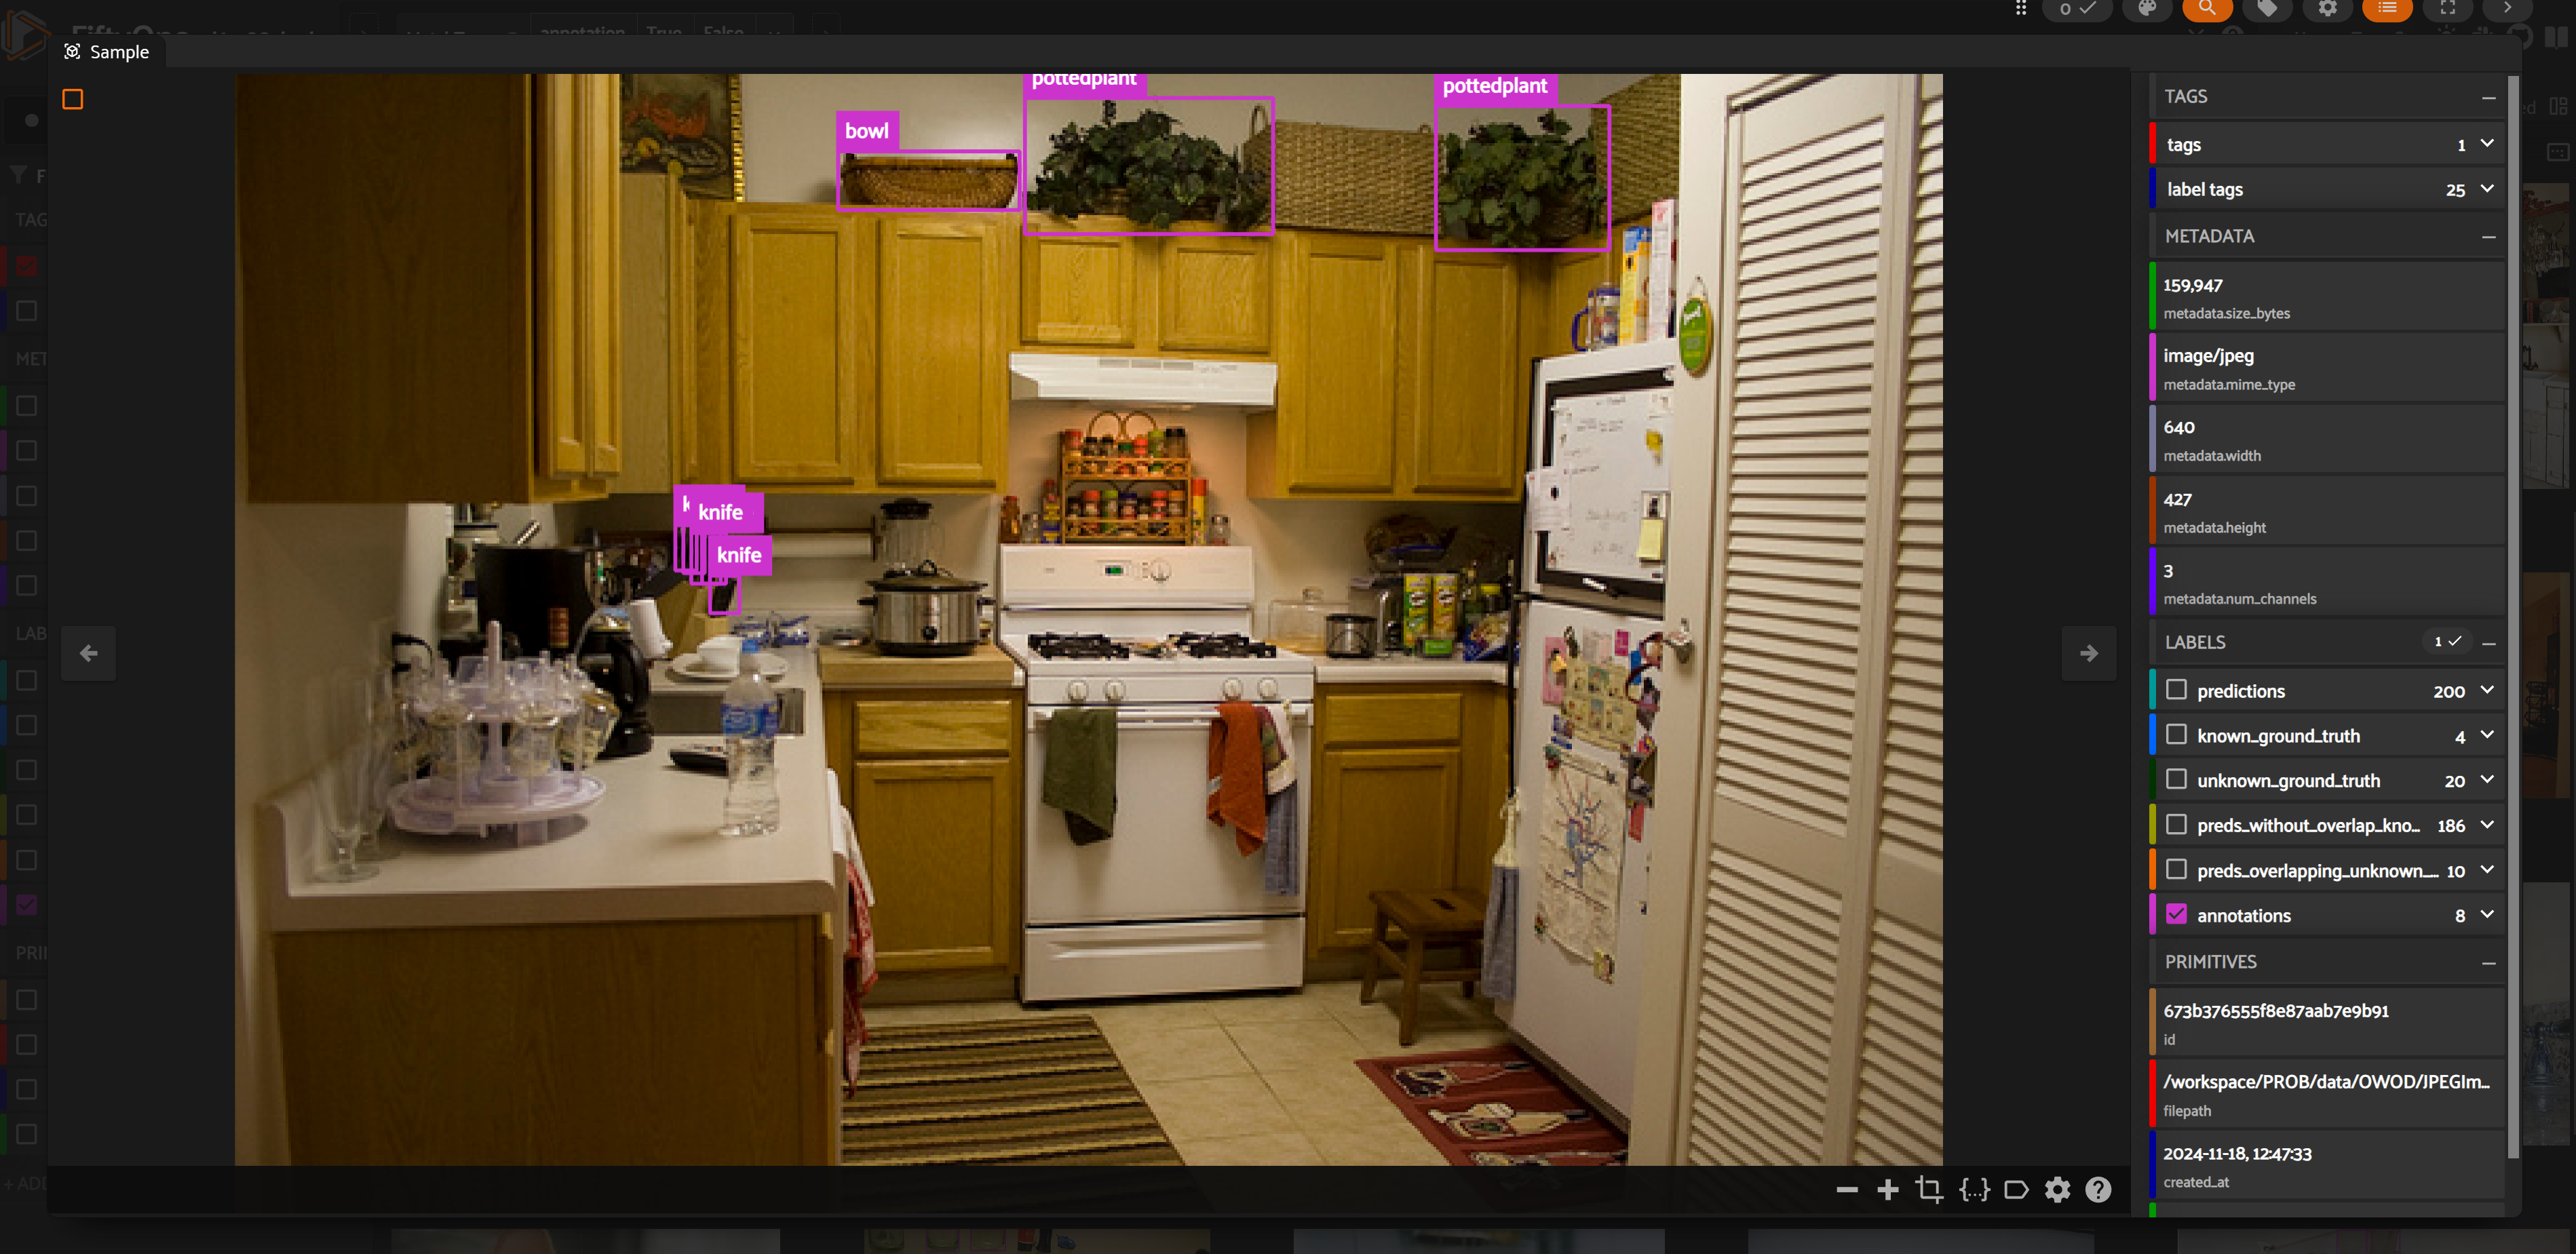

In [ ]:
session.view = annotation_view

In [40]:
# free memory
torch.cuda.empty_cache()

# Task 2